# SaaS Business Analytics — Business EDA

This notebook turns the cleaned SaaS data into business-facing findings for management: revenue performance, customer value, subscription health, product engagement, and support operations.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT=Path('..'); CLEAN=ROOT/'data'/'cleaned'
customers=pd.read_csv(CLEAN/'customers_clean.csv',parse_dates=['Signup_Date'])
plans=pd.read_csv(CLEAN/'plans_clean.csv')
subscriptions=pd.read_csv(CLEAN/'subscriptions_clean.csv',parse_dates=['Start_Date','End_Date'])
payments=pd.read_csv(CLEAN/'payments_clean.csv',parse_dates=['Payment_Date'])
usage=pd.read_csv(CLEAN/'usage_clean.csv',parse_dates=['Event_Date'])
support=pd.read_csv(CLEAN/'support_clean.csv',parse_dates=['Ticket_Date'])

## KPI scorecard

In [3]:
paid=payments[payments.Payment_Status.eq('Paid')]
active=subscriptions[subscriptions.Status.eq('Active')]
churned=subscriptions[subscriptions.Status.eq('Churned')]
positive_customers=payments.groupby(payments.columns[1] if False else 'Payment_Id') if False else payments.merge(subscriptions[['Subscription_Id','Customer_Id']],on='Subscription_Id').groupby('Customer_Id').Amount.sum()
kpis=pd.Series({
 'Net collected revenue': payments.loc[payments.Payment_Status.isin(['Paid','Refunded']), 'Amount'].sum(),
 'Paid revenue': paid.Amount.sum(),
 'Refund value': payments.loc[payments.Payment_Status.eq('Refunded'),'Amount'].abs().sum(),
 'Active subscriptions': len(active),
 'Churn rate %': len(churned)/len(subscriptions)*100,
 'Customers with positive net revenue': (positive_customers>0).sum(),
 'Avg support resolution (min)': support.Resolution_Time.mean(),
 'Usage events': len(usage)
})
kpis.round(2)

Net collected revenue                  122731.00
Paid revenue                           258370.00
Refund value                           135639.00
Active subscriptions                     1043.00
Churn rate %                               10.07
Customers with positive net revenue      1071.00
Avg support resolution (min)               36.21
Usage events                            24756.00
dtype: float64

## Revenue by plan, country, segment, and industry

In [4]:
fact=payments.merge(subscriptions[['Subscription_Id','Customer_Id','Plan_Id']],on='Subscription_Id').merge(customers[['Customer_Id','Country','Segment','Industry']],on='Customer_Id').merge(plans[['Plan_Id','Plan_Name']],on='Plan_Id')
paid_fact=fact[fact.Payment_Status.eq('Paid')].copy()
for dim in ['Plan_Name','Country','Segment','Industry']:
    print('\n',dim)
    display(paid_fact.groupby(dim,dropna=False).Amount.sum().sort_values(ascending=False).to_frame('Revenue').round(2))


 Plan_Name


,Revenue
Plan_Name,
Enterprise,188622.0
Pro,59250.0
Basic,10498.0



 Country


,Revenue
Country,
United States,91338.0
United Kingdom,57924.0
Unknown,55454.0
Canada,53654.0



 Segment


,Revenue
Segment,
SMB,99319.0
Enterprise,80160.0
Mid-Market,78891.0



 Industry


,Revenue
Industry,
Healthcare,54025.0
Saas,52417.0
Unknown,40582.0
Finance,39554.0
Logistics,36109.0
E-Commerce,35683.0


## Monthly revenue trend and growth

In [5]:
monthly=paid_fact.groupby(paid_fact.Payment_Date.dt.to_period('M').astype(str)).Amount.sum().rename('Revenue').to_frame()
monthly['MoM_Growth_%']=monthly.Revenue.pct_change().mul(100)
monthly.round(2)

,Revenue,MoM_Growth_%
Payment_Date,,
2025-01,9258.0,NaN
2025-02,11574.0,25.02
2025-03,14543.0,25.65
2025-04,20725.0,42.51
2025-05,21021.0,1.43
2025-06,21716.0,3.31
2025-07,17425.0,-19.76
2025-08,23457.0,34.62
2025-09,21848.0,-6.86


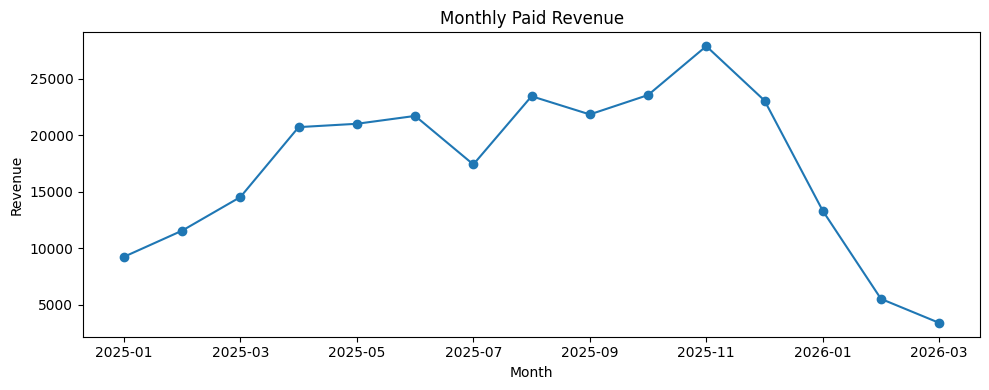

In [6]:
ax=monthly.Revenue.plot(figsize=(10,4),marker='o',title='Monthly Paid Revenue')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue'); plt.tight_layout(); plt.show()

## Customer value and concentration

In [7]:
customer_rev=paid_fact.groupby(['Customer_Id','Country','Segment']).Amount.sum().sort_values(ascending=False).rename('Revenue').reset_index()
customer_rev['Revenue_Rank']=customer_rev.Revenue.rank(method='dense',ascending=False).astype(int)
customer_rev.head(10)

,Customer_Id,Country,Segment,Revenue,Revenue_Rank
0,CUST_2007,United Kingdom,SMB,1996.0,1
1,CUST_3483,United Kingdom,Mid-Market,1996.0,1
2,CUST_3245,United Kingdom,Enterprise,1996.0,1
3,CUST_2267,United Kingdom,Enterprise,1996.0,1
4,CUST_2034,United States,Enterprise,1497.0,2
5,CUST_3068,Canada,Mid-Market,1497.0,2
6,CUST_3188,Unknown,Enterprise,1497.0,2
7,CUST_2050,Unknown,SMB,1497.0,2
8,CUST_3098,United Kingdom,Enterprise,1497.0,2
9,CUST_3135,United Kingdom,Mid-Market,1497.0,2


In [8]:
top10_share=customer_rev.head(10).Revenue.sum()/customer_rev.Revenue.sum()*100
print(f'Top 10 customers revenue share: {top10_share:.2f}%')

Top 10 customers revenue share: 6.57%


## Subscription health

In [9]:
sub_health=subscriptions.groupby('Status').size().rename('Subscriptions').to_frame()
sub_health['Share_%']=sub_health.Subscriptions/sub_health.Subscriptions.sum()*100
sub_health.round(2)

,Subscriptions,Share_%
Status,,
Active,1043,69.53
Cancelled,306,20.40
Churned,151,10.07


In [10]:
plan_churn=subscriptions.groupby('Plan_Id').agg(Total=('Subscription_Id','count'),Churned=('Status',lambda s:(s=='Churned').sum()))
plan_churn['Churn_Rate_%']=plan_churn.Churned/plan_churn.Total*100
plan_churn.merge(plans[['Plan_Id','Plan_Name']],on='Plan_Id').sort_values('Churn_Rate_%',ascending=False).round(2)

,Plan_Id,Total,Churned,Churn_Rate_%,Plan_Name
1,p_ent,394,40,10.15,Enterprise
0,p_basic,357,36,10.08,Basic
2,p_pro,749,75,10.01,Pro


## Product engagement

In [11]:
feature=usage.groupby('Feature_Name').agg(Events=('Usage_Id','count'),Logins=('Login_Count','sum'),Session_Minutes=('Session_Minutes','sum')).sort_values('Events',ascending=False)
feature['Avg_Session_Minutes']=feature.Session_Minutes/feature.Events
feature.round(2)

,Events,Logins,Session_Minutes,Avg_Session_Minutes
Feature_Name,,,,
dashboard_view,4849,20938,298179.34,61.49
team_invite,4825,21379,298127.76,61.79
billing_edit,4724,20621,293712.18,62.17
export_csv,4717,20614,293915.11,62.31
api_post,4699,20330,293399.79,62.44
Unknown,942,4023,57507.57,61.05


In [12]:
monthly_usage=usage.groupby(usage.Event_Date.dt.to_period('M').astype(str)).agg(Events=('Usage_Id','count'),Sessions=('Session_Minutes','sum'))
monthly_usage.round(2)

,Events,Sessions
Event_Date,,
2025-01,2162,134010.66
2025-02,1938,120662.01
2025-03,2257,142137.09
2025-04,2057,129878.87
2025-05,2233,136333.18
2025-06,2069,128063.30
2025-07,2235,136759.52
2025-08,2215,138616.92
2025-09,2136,131120.53


## Support operations

In [13]:
support_summary=support.groupby(['Priority','Status']).size().rename('Tickets').reset_index()
category=support.groupby('Category').agg(Tickets=('Ticket_Id','count'),Avg_Resolution_Min=('Resolution_Time','mean')).sort_values('Tickets',ascending=False)
category.round(2)

,Tickets,Avg_Resolution_Min
Category,,
Api Down,214,34.81
Billing Bug,197,34.95
Login Issue,192,38.13
Feature Request,181,37.18


In [14]:
ticket_customer=support.groupby('Customer_Id').agg(Tickets=('Ticket_Id','count'),Avg_Resolution=('Resolution_Time','mean'))
customer_rev2=customer_rev.set_index('Customer_Id')
combined=customer_rev2.join(ticket_customer,how='left').fillna({'Tickets':0})
combined.sort_values('Tickets',ascending=False).head(10)

,Country,Segment,Revenue,Revenue_Rank,Tickets,Avg_Resolution
Customer_Id,,,,,,
CUST_2046,Canada,Enterprise,998.0,3,3.0,57.000000
CUST_3496,United States,Enterprise,998.0,3,3.0,63.000000
CUST_2533,United Kingdom,Enterprise,29.0,12,3.0,33.333333
CUST_2640,United Kingdom,SMB,29.0,12,3.0,28.333333
CUST_2647,United States,Mid-Market,29.0,12,3.0,25.666667
CUST_2576,United Kingdom,SMB,29.0,12,3.0,41.666667
CUST_3088,Unknown,Mid-Market,998.0,3,3.0,26.000000
CUST_3074,United Kingdom,SMB,998.0,3,3.0,31.666667
CUST_2462,Unknown,Enterprise,998.0,3,3.0,11.666667


## Business interpretation checklist
Use the tables above to answer: (1) Which plans and customer segments generate revenue? (2) Is revenue growing or contracting month over month? (3) How concentrated is revenue among top customers? (4) Which plans have the highest churn rate? (5) Which product features drive the most engagement? (6) Where is support demand concentrated, and does resolution time differ by category/priority? These questions become the basis for SQL queries and Power BI KPI cards.